In [ ]:
# =============================================================================
#  BOREHOLE ANALYSIS
#  Framework: TensorFlow / Keras  |  Python 3.11.7
#
#  DATASET STRATEGY:
#  Real collected data   : 103 boreholes (from field survey)

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — IMPORT LIBRARIES
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 400
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"   TensorFlow version: {tf.__version__}")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

   TensorFlow version: 2.13.0


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — LOAD REAL DATA
# ══════════════════════════════════════════════════════════════════════════════
FILE_PATH = "Data.csv"
data = pd.read_csv(FILE_PATH)
print(f"\n Real data loaded: {data.shape[0]} boreholes, {data.shape[1]} columns")


 Real data loaded: 103 boreholes, 22 columns


In [6]:
data.head()

,Year_Installed,Age,Depth_ft,Gen_KVA,Capacity_of_Sumo_HP,Pump_Hours,Usage_Frequency_Per_Day,Is_Continous,Downtime(days),Cost_Naira,...,GEN_ES,SOLAR_ES,Maintenance_Freq,Pipe_Bfreq,Pannel_Bfreq,Sumo_Bfreq,Pipe_Fault,Sumo_Fault,Panel_Fault,Failure
0,2001,25,760,0.0,30.0,12,3,1,3.0,"₦ 1,500,000",...,0,0,1.0,0.0,0.0,0.33,0,1,0,1
1,2014,12,750,100.0,30.0,10,2,1,14.0,"₦ 1,900,000",...,1,0,1.0,0.0,4.0,4.00,0,1,1,1
2,2015,11,730,0.0,30.0,6,1,0,21.0,"₦ 1,500,000",...,0,0,1.0,0.0,0.0,0.50,0,1,0,1
3,2024,2,750,0.0,1.5,6,1,0,30.0,"₦ 400,000",...,0,1,0.0,0.0,0.5,0.00,0,0,0,1
4,2024,2,750,100.0,10.0,5,2,0,0.0,₦ 0,...,1,0,0.0,0.0,0.0,0.00,0,0,0,0


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — CLEAN DATA
# ══════════════════════════════════════════════════════════════════════════════
print("\n--- SECTION 3: Cleaning Real Data ---")

# Fix Cost_Naira: remove ₦ symbol and commas → convert to number
data['Cost_Naira'] = (
    data['Cost_Naira'].astype(str)
    .str.replace('₦', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# Fill 2 missing values with column median
data['Gen_KVA'].fillna(data['Gen_KVA'].median(), inplace=True)
data['Maintenance_Freq'].fillna(data['Maintenance_Freq'].median(), inplace=True)

# Drop Year_Installed (Age already captures this)
data.drop(columns=['Year_Installed'], inplace=True)


--- SECTION 3: Cleaning Real Data ---


In [8]:
# ── ADD TOTAL INSTALLATION COST ──────────────────────────────────────────────
# These are the REAL total installation costs collected from the field survey.
# Rows 8, 33, and 103 were missing — filled with the average of all other values (₦13,577,000).
TOTAL_INSTALLATION_COSTS = [
    3000000, 5400000, 8500000, 14500000, 13000000, 22000000, 15000000,
    13577000, 9500000, 14000000, 13000000, 22000000, 20000000, 17500000, 30000000,
    12500000, 20000000, 22000000, 8500000, 23000000, 23500000, 7000000,
    9000000, 6800000, 6500000, 8500000, 7000000, 7000000, 3500000, 23000000,
    12000000, 8000000, 13577000, 9000000, 8500000, 10000000, 29000000, 9000000,
    21000000, 9000000, 12000000, 8000000, 7500000, 7500000, 8000000, 8500000,
    11500000, 12000000, 7500000, 8000000, 13000000, 8000000, 8500000, 21500000,
    10500000, 8200000, 8000000, 7800000, 8100000, 9500000, 9000000, 9200000,
    8900000, 9600000, 9300000, 24000000, 22000000, 18000000, 25000000, 24000000,
    23000000, 24500000, 21000000, 25000000, 24000000, 23500000, 23000000,
    20000000, 24000000, 25000000, 24500000, 7700000, 11000000, 11000000,
    11200000, 22000000, 20000000, 9500000, 8000000, 14000000, 10000000,
    9000000, 17000000, 8500000, 13000000, 8500000, 9000000, 9500000, 9000000,
    7500000, 12000000, 9500000,
    13577000]

data['Total_Installation_Cost'] = TOTAL_INSTALLATION_COSTS

print("Cost_Naira cleaned")
print("Missing values filled")
print("Year_Installed dropped")
print(f"Total_Installation_Cost added")
print(f" Range: ₦{data['Total_Installation_Cost'].min():,.0f} — ₦{data['Total_Installation_Cost'].max():,.0f}")
print(f" Mean:  ₦{data['Total_Installation_Cost'].mean():,.0f}")

Cost_Naira cleaned
Missing values filled
Year_Installed dropped
Total_Installation_Cost added
 Range: ₦3,000,000 — ₦30,000,000
 Mean:  ₦13,577,000


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — CREATE GRAPH HELPER COLUMNS
# ══════════════════════════════════════════════════════════════════════════════

def classify_fault(row):
    faults = []
    if row['Pipe_Fault']  == 1: faults.append('Pipe')
    if row['Sumo_Fault']  == 1: faults.append('Sumo')
    if row['Panel_Fault'] == 1: faults.append('Panel')
    return 'No Fault' if not faults else ' + '.join(faults)
data['Fault_Type']       = data.apply(classify_fault, axis=1)
data['Ownership_Label']  = data['Ownership'].map({0: 'Public', 1: 'Private'})

def energy_label(row):
    if row['NEPA_ES']  == 1: return 'NEPA/Grid'
    if row['GEN_ES']   == 1: return 'Generator'
    if row['SOLAR_ES'] == 1: return 'Solar'
    return 'Unknown'
data['Energy_Source'] = data.apply(energy_label, axis=1)

In [11]:
data.tail(5)

,Age,Depth_ft,Gen_KVA,Capacity_of_Sumo_HP,Pump_Hours,Usage_Frequency_Per_Day,Is_Continous,Downtime(days),Cost_Naira,Ownership,...,Pannel_Bfreq,Sumo_Bfreq,Pipe_Fault,Sumo_Fault,Panel_Fault,Failure,Total_Installation_Cost,Fault_Type,Ownership_Label,Energy_Source
98,3,700,50.0,10.0,8,1,0,25.0,1100000.0,0,...,0.00,0.50,0,1,0,1,9000000,Sumo,Public,NEPA/Grid
99,4,720,100.0,10.0,10,2,0,38.0,1200000.0,0,...,0.00,0.33,0,1,0,1,7500000,Sumo,Public,NEPA/Grid
100,7,750,50.0,10.0,8,2,0,17.0,800000.0,0,...,0.33,0.33,0,1,1,1,12000000,Sumo + Panel,Public,NEPA/Grid
101,1,700,80.0,10.0,7,2,0,0.0,0.0,0,...,0.00,0.00,0,0,0,0,9500000,No Fault,Public,NEPA/Grid
102,4,720,50.0,10.0,10,2,0,15.0,1500000.0,0,...,0.00,0.50,0,1,0,1,13577000,Sumo,Public,NEPA/Grid



--- SECTION 6: Plotting All 9 Client Graphs ---


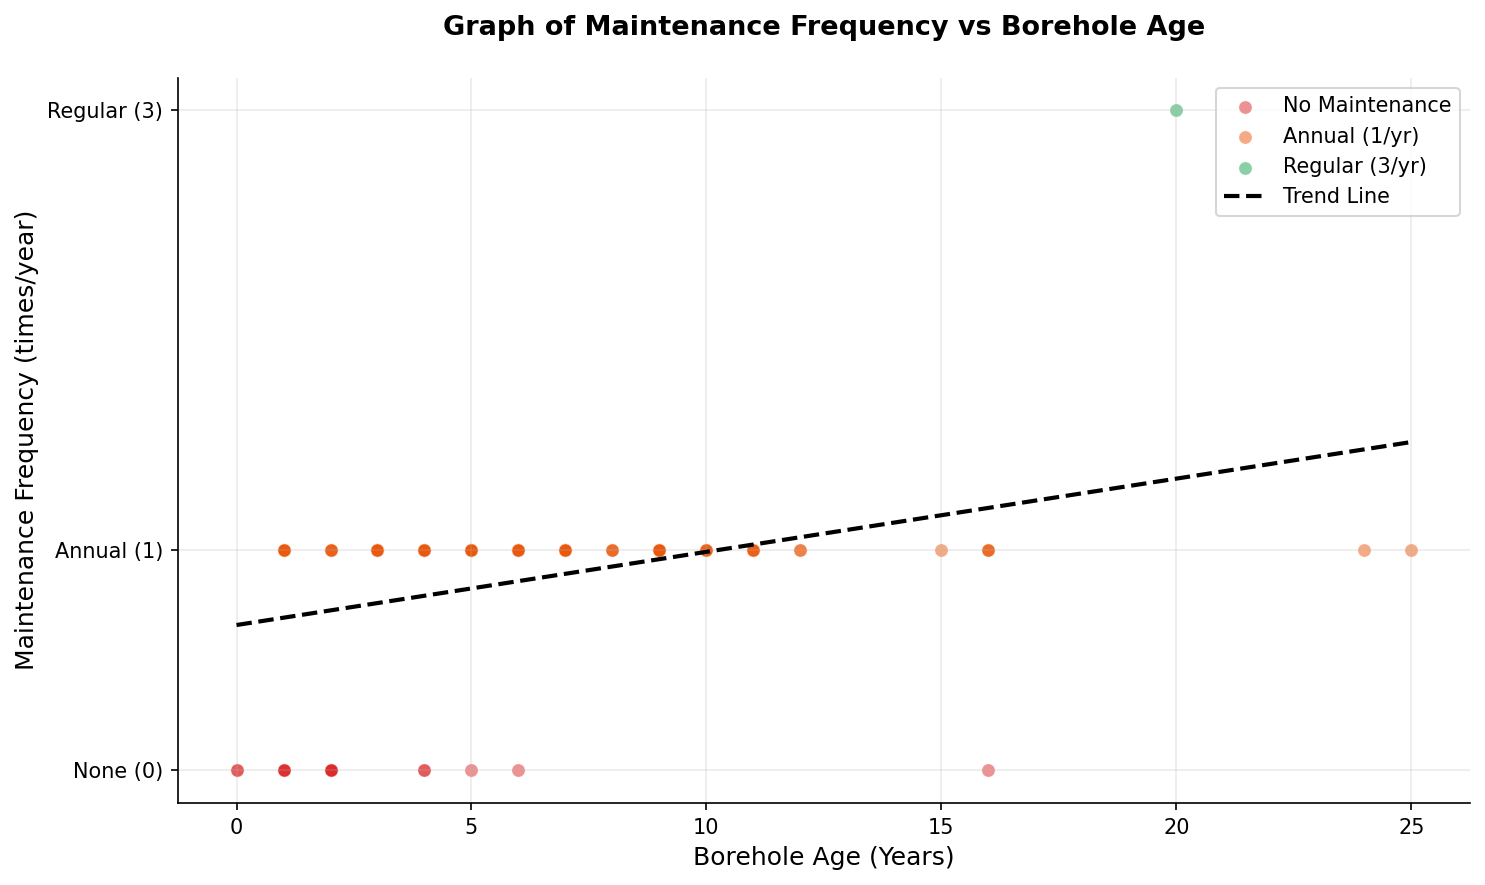

   ✅ Graph 1 saved


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — PLOT ALL 9 CLIENT GRAPHS
# ══════════════════════════════════════════════════════════════════════════════
print("\n--- SECTION 6: Plotting All 9 Client Graphs ---")

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
C = {
    'blue':   '#2563EB', 'red':    '#DC2626',
    'green':  '#16A34A', 'orange': '#EA580C',
    'purple': '#7C3AED', 'teal':   '#0D9488',
    'gray':   '#6B7280', 'yellow': '#CA8A04',
}

# ── GRAPH 1: Maintenance Frequency vs Borehole Age ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors_maint = {0.0: C['red'], 1.0: C['orange'], 3.0: C['green']}
labels_maint = {0.0: 'No Maintenance', 1.0: 'Annual (1/yr)', 3.0: 'Regular (3/yr)'}
for freq_val, grp in data.groupby('Maintenance_Freq'):
    ax.scatter(grp['Age'], grp['Maintenance_Freq'],
               color=colors_maint.get(freq_val, C['gray']),
               label=labels_maint.get(freq_val, str(freq_val)),
               s=40, alpha=0.5, edgecolors='white', linewidth=0.3)
z = np.polyfit(data['Age'], data['Maintenance_Freq'], 1)
age_line = np.linspace(data['Age'].min(), data['Age'].max(), 100)
ax.plot(age_line, np.poly1d(z)(age_line), color='black', lw=2,
        linestyle='--', label='Trend Line')
ax.set_title('Graph of Maintenance Frequency vs Borehole Age\n', fontsize=13, fontweight='bold')
ax.set_xlabel('Borehole Age (Years)', fontsize=12)
ax.set_ylabel('Maintenance Frequency (times/year)', fontsize=12)
ax.set_yticks([0, 1, 3])
ax.set_yticklabels(['None (0)', 'Annual (1)', 'Regular (3)'])
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('graph1_maintenance_freq_vs_age.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 1 saved")

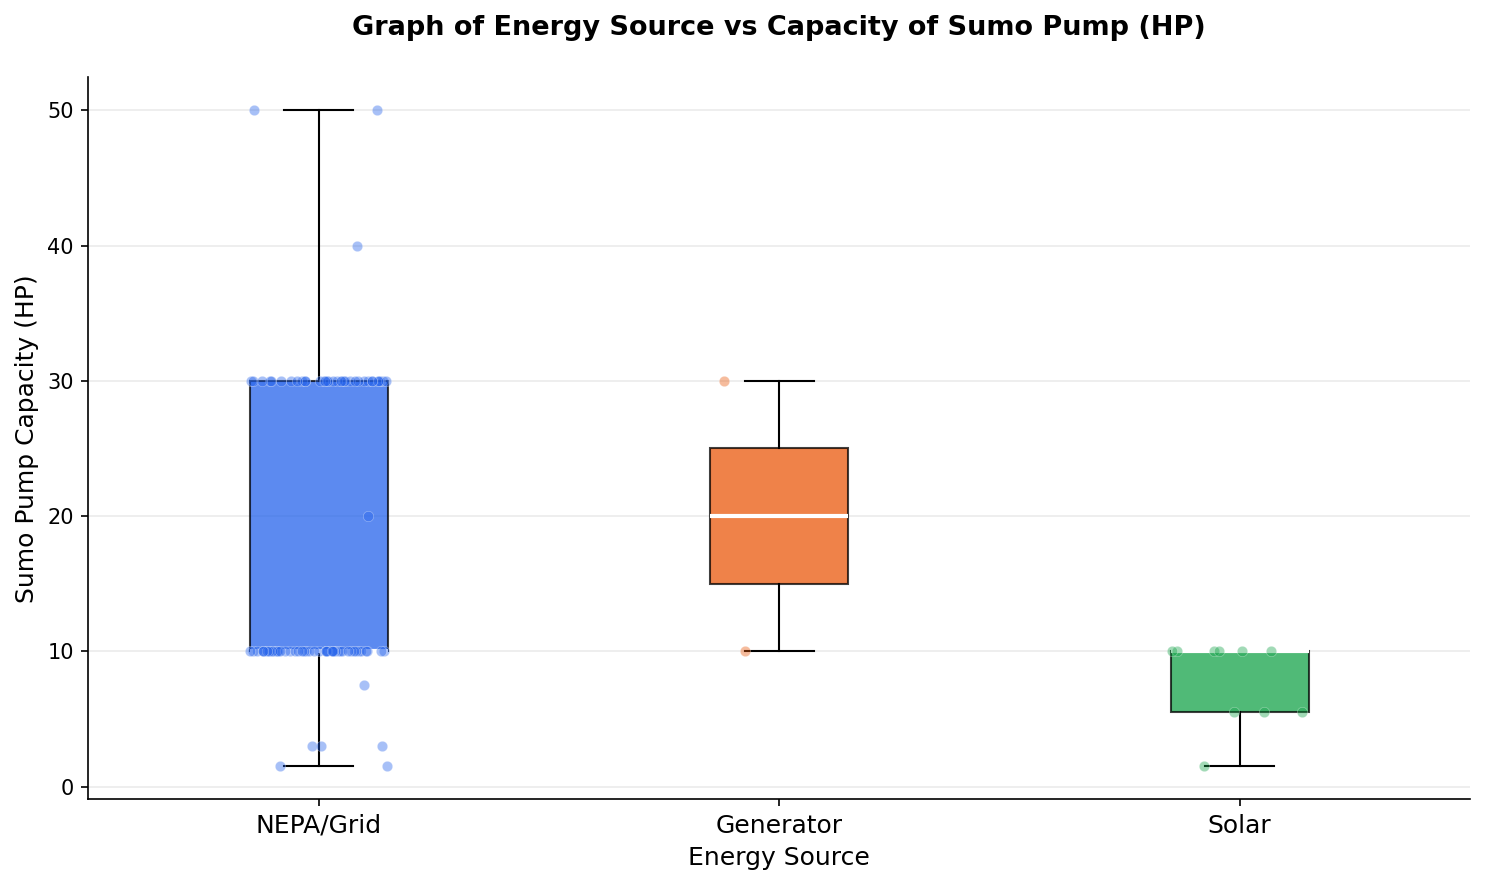

   ✅ Graph 2 saved


In [14]:
# ── GRAPH 2: Energy Source vs Capacity of Sumo ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
energy_order = ['NEPA/Grid', 'Generator', 'Solar']
energy_colors = [C['blue'], C['orange'], C['green']]
energy_data = [data[data['Energy_Source']==e]['Capacity_of_Sumo_HP'].values for e in energy_order]
bp = ax.boxplot(energy_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], energy_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (data_pts, color) in enumerate(zip(energy_data, energy_colors), 1):
    jitter = np.random.uniform(-0.15, 0.15, len(data_pts))
    ax.scatter(i+jitter, data_pts, color=color, s=25, alpha=0.4,
               edgecolors='white', linewidth=0.3, zorder=3)
ax.set_xticks([1,2,3]); ax.set_xticklabels(energy_order, fontsize=12)
ax.set_title('Graph of Energy Source vs Capacity of Sumo Pump (HP)\n', fontsize=13, fontweight='bold')
ax.set_xlabel('Energy Source', fontsize=12)
ax.set_ylabel('Sumo Pump Capacity (HP)', fontsize=12)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('graph2_energy_vs_sumo_capacity.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 2 saved")

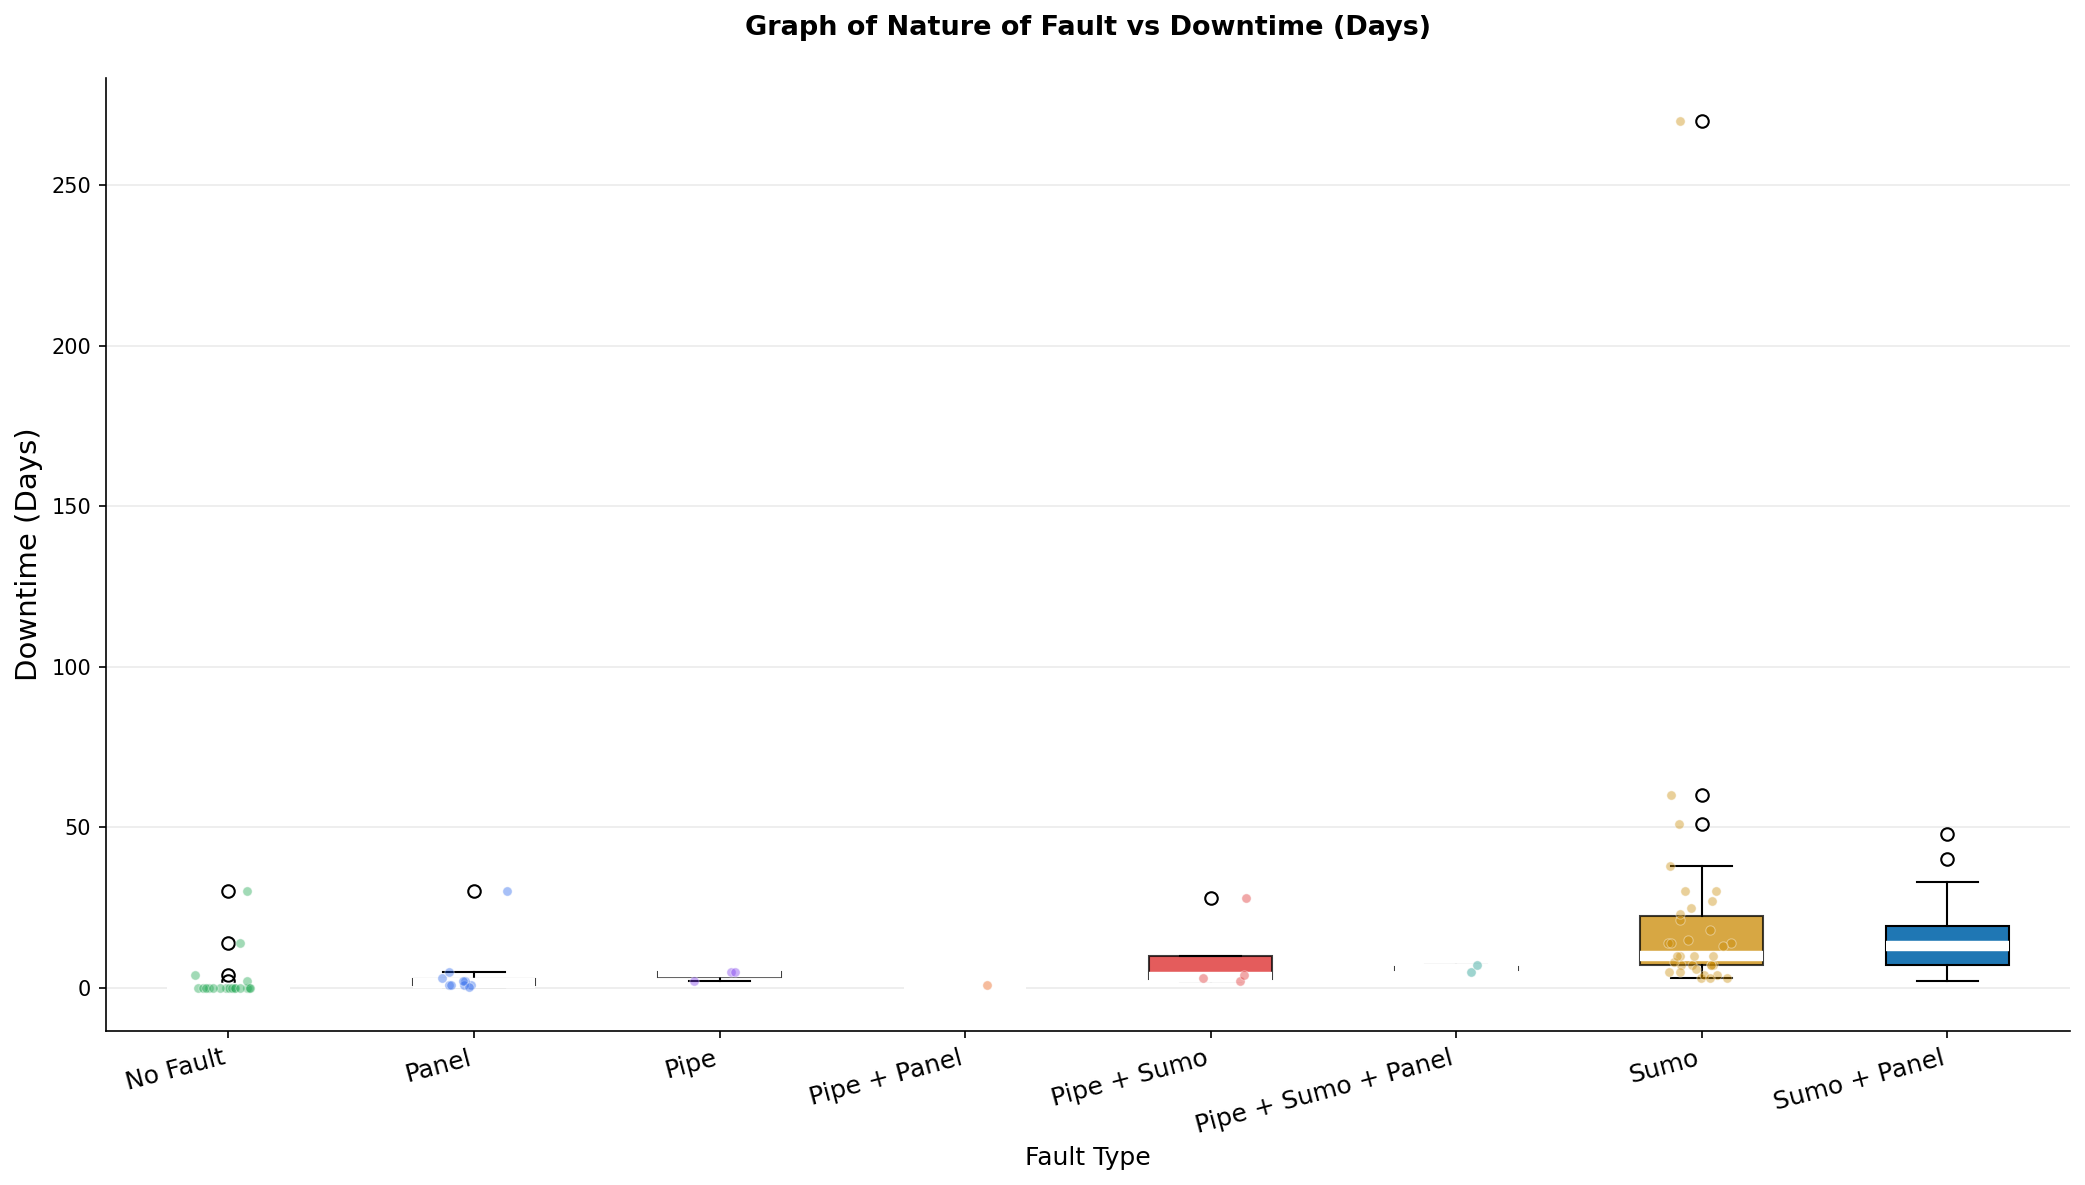

   ✅ Graph 3 saved


In [15]:
# ── GRAPH 3: Nature of Fault vs Downtime ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fault_order = sorted(data['Fault_Type'].unique())
fault_colors = [C['green'],C['blue'],C['purple'],C['orange'],C['red'],C['teal'],C['yellow']][:len(fault_order)]
fault_data = [data[data['Fault_Type']==f]['Downtime(days)'].values for f in fault_order]
bp = ax.boxplot(fault_data, patch_artist=True, medianprops=dict(color='white', linewidth=5))
for patch, color in zip(bp['boxes'], fault_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (data_pts, color) in enumerate(zip(fault_data, fault_colors), 1):
    jitter = np.random.uniform(-0.15, 0.15, len(data_pts))
    ax.scatter(i+jitter, data_pts, color=color, s=20, alpha=0.4,
               edgecolors='white', linewidth=0.5, zorder=5)
ax.set_xticks(range(1, len(fault_order)+1))
ax.set_xticklabels(fault_order, fontsize=12, rotation=15, ha='right')
ax.set_title('Graph of Nature of Fault vs Downtime (Days)\n', fontsize=13, fontweight='bold')
ax.set_xlabel('Fault Type', fontsize=12); ax.set_ylabel('Downtime (Days)', fontsize=14)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('graph3_fault_vs_downtime.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 3 saved")

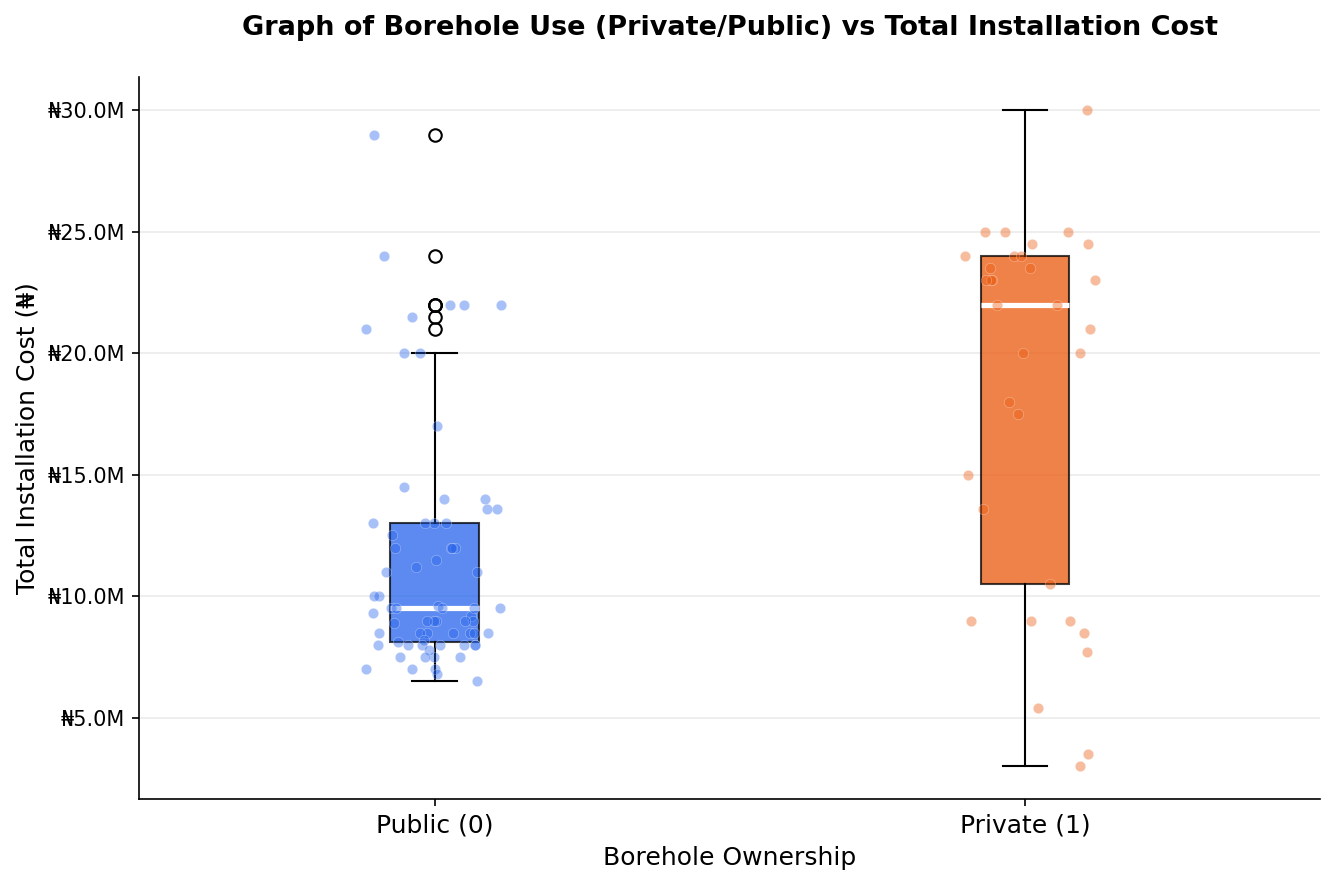

   ✅ Graph 4 saved


In [16]:
# ── GRAPH 4: Ownership vs Total Installation Cost ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
use_data = [data[data['Ownership']==0]['Total_Installation_Cost'].values,
            data[data['Ownership']==1]['Total_Installation_Cost'].values]
use_colors = [C['blue'], C['orange']]
bp = ax.boxplot(use_data, patch_artist=True, medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], use_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (data_pts, color) in enumerate(zip(use_data, use_colors), 1):
    jitter = np.random.uniform(-0.12, 0.12, len(data_pts))
    ax.scatter(i+jitter, data_pts, color=color, s=25, alpha=0.4,
               edgecolors='white', linewidth=0.3, zorder=3)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'₦{x/1_000_000:.1f}M' if x>=1_000_000 else f'₦{x/1_000:.0f}K'))
ax.set_xticks([1,2]); ax.set_xticklabels(['Public (0)', 'Private (1)'], fontsize=12)
ax.set_title('Graph of Borehole Use (Private/Public) vs Total Installation Cost\n', fontsize=13, fontweight='bold')
ax.set_xlabel('Borehole Ownership', fontsize=12)
ax.set_ylabel('Total Installation Cost (₦)', fontsize=12)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('graph4_ownership_vs_installation_cost.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 4 saved")

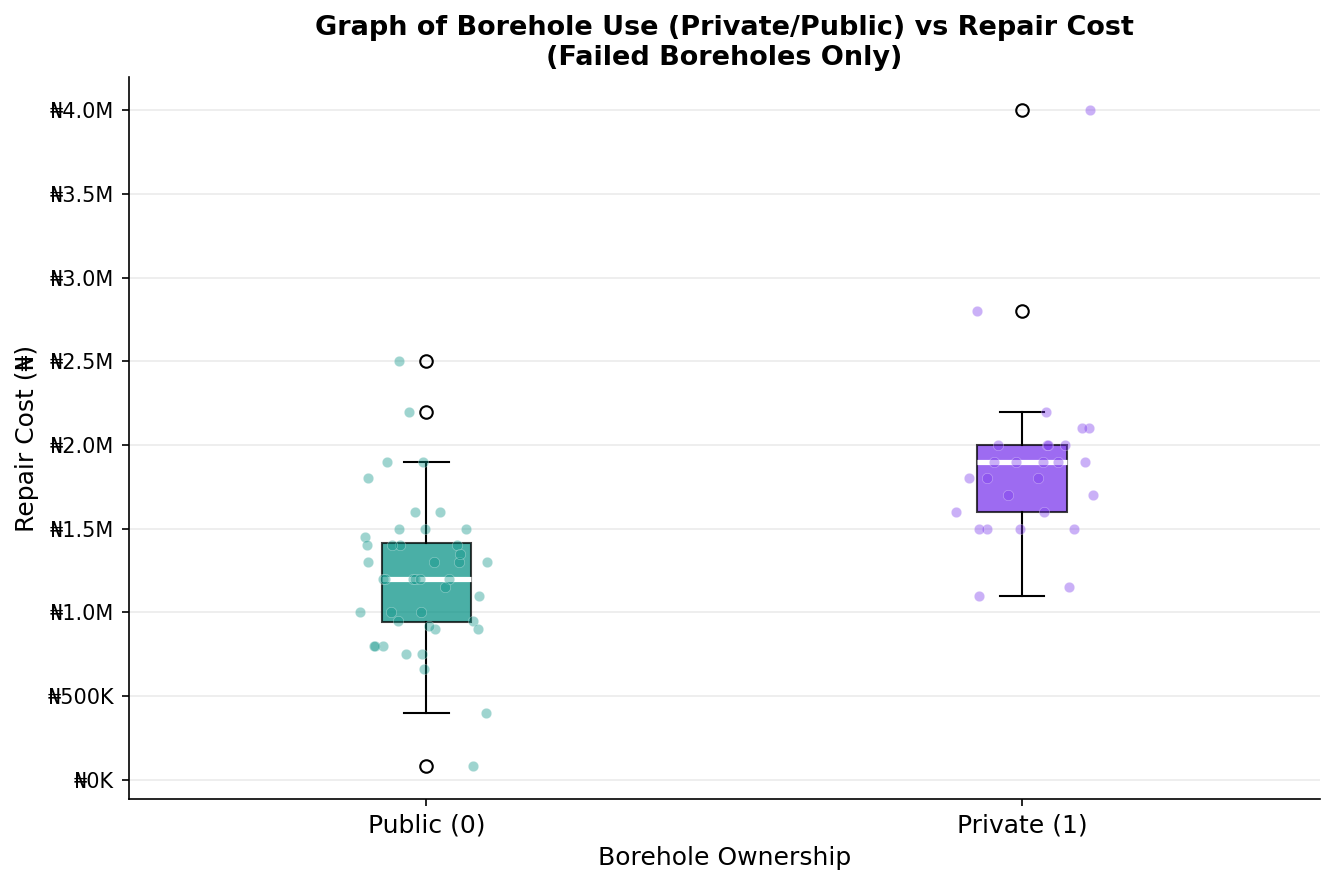

   ✅ Graph 5 saved


In [19]:
# ── GRAPH 5: Ownership vs Repair Cost (failed boreholes only) ───────────────
fig, ax = plt.subplots(figsize=(9, 6))
df_failed = data[data['Failure']==1]
repair_data = [df_failed[df_failed['Ownership']==0]['Cost_Naira'].values,
               df_failed[df_failed['Ownership']==1]['Cost_Naira'].values]
repair_colors = [C['teal'], C['purple']]
bp = ax.boxplot(repair_data, patch_artist=True, medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], repair_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (data_pts, color) in enumerate(zip(repair_data, repair_colors), 1):
    jitter = np.random.uniform(-0.12, 0.12, len(data_pts))
    ax.scatter(i+jitter, data_pts, color=color, s=25, alpha=0.4,
               edgecolors='white', linewidth=0.3, zorder=3)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'₦{x/1_000_000:.1f}M' if x>=1_000_000 else f'₦{x/1_000:.0f}K'))
ax.set_xticks([1,2]); ax.set_xticklabels(['Public (0)','Private (1)'], fontsize=12)
ax.set_title('Graph of Borehole Use (Private/Public) vs Repair Cost\n(Failed Boreholes Only)', fontsize=13, fontweight='bold')
ax.set_xlabel('Borehole Ownership', fontsize=12)
ax.set_ylabel('Repair Cost (₦)', fontsize=12)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('graph5_ownership_vs_repair_cost.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 5 saved")


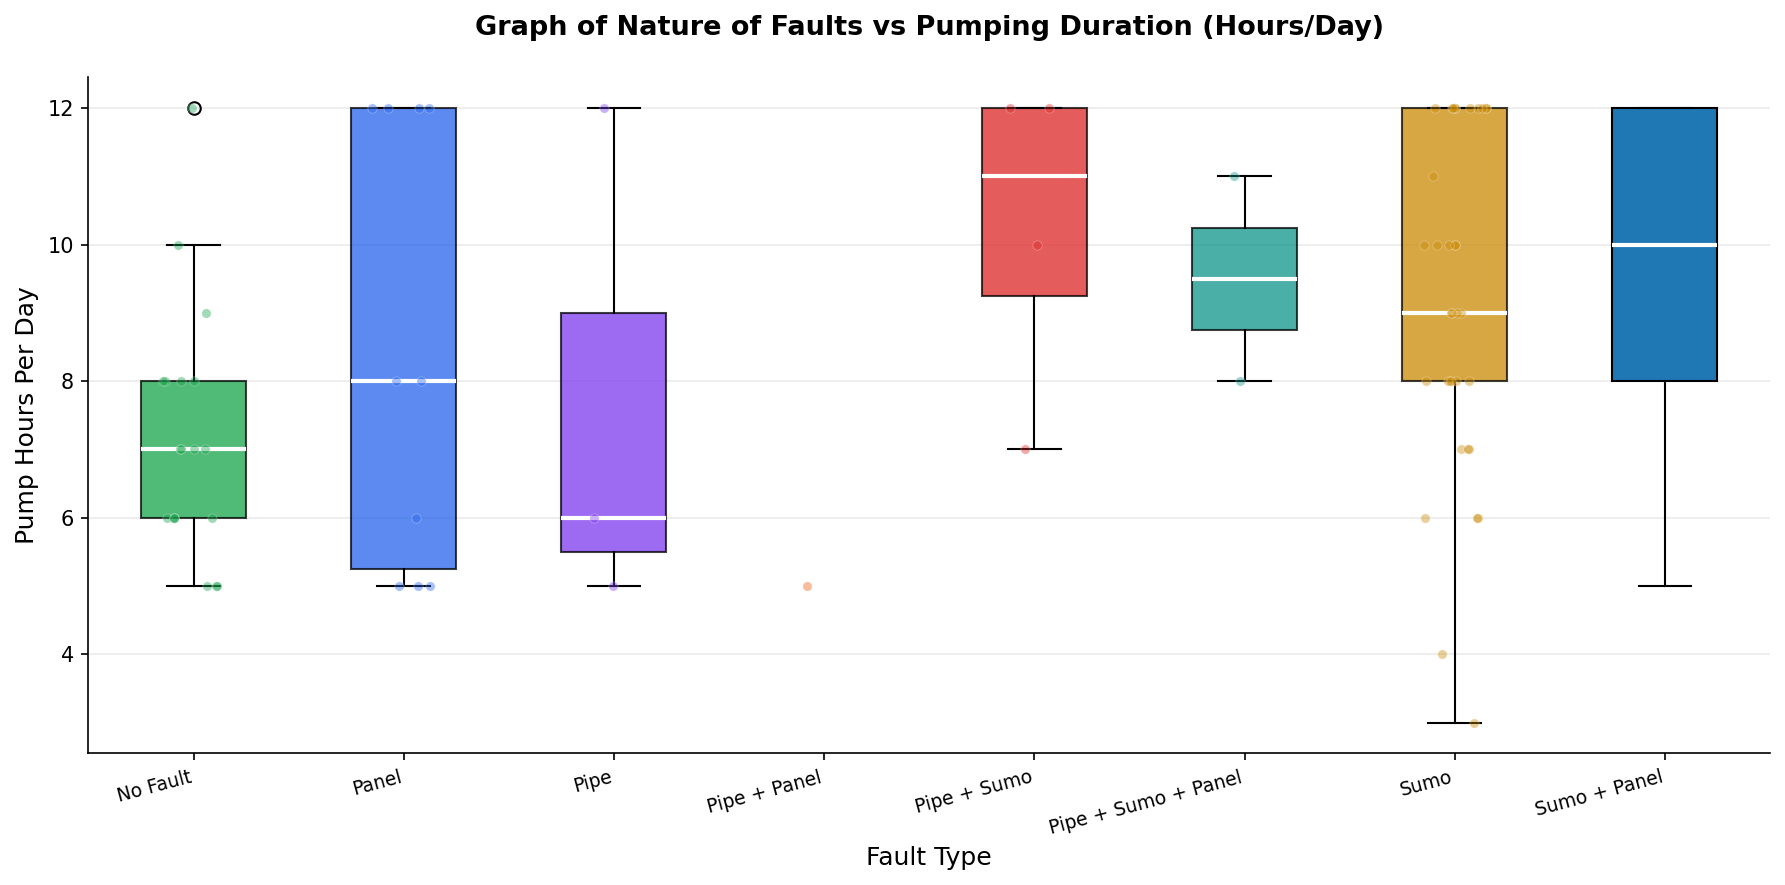

   ✅ Graph 6 saved


In [22]:
# ── GRAPH 6: Nature of Faults vs Pumping Duration ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fault_pump_data = [data[data['Fault_Type']==f]['Pump_Hours'].values for f in fault_order]
bp = ax.boxplot(fault_pump_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], fault_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (data_pts, color) in enumerate(zip(fault_pump_data, fault_colors), 1):
    jitter = np.random.uniform(-0.15, 0.15, len(data_pts))
    ax.scatter(i+jitter, data_pts, color=color, s=20, alpha=0.4,
               edgecolors='white', linewidth=0.3, zorder=3)
ax.set_xticks(range(1, len(fault_order)+1))
ax.set_xticklabels(fault_order, fontsize=9, rotation=15, ha='right')
ax.set_title('Graph of Nature of Faults vs Pumping Duration (Hours/Day)\n', fontsize=13, fontweight='bold')
ax.set_xlabel('Fault Type', fontsize=12); ax.set_ylabel('Pump Hours Per Day', fontsize=12)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('graph6_fault_vs_pumping_duration.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 6 saved")


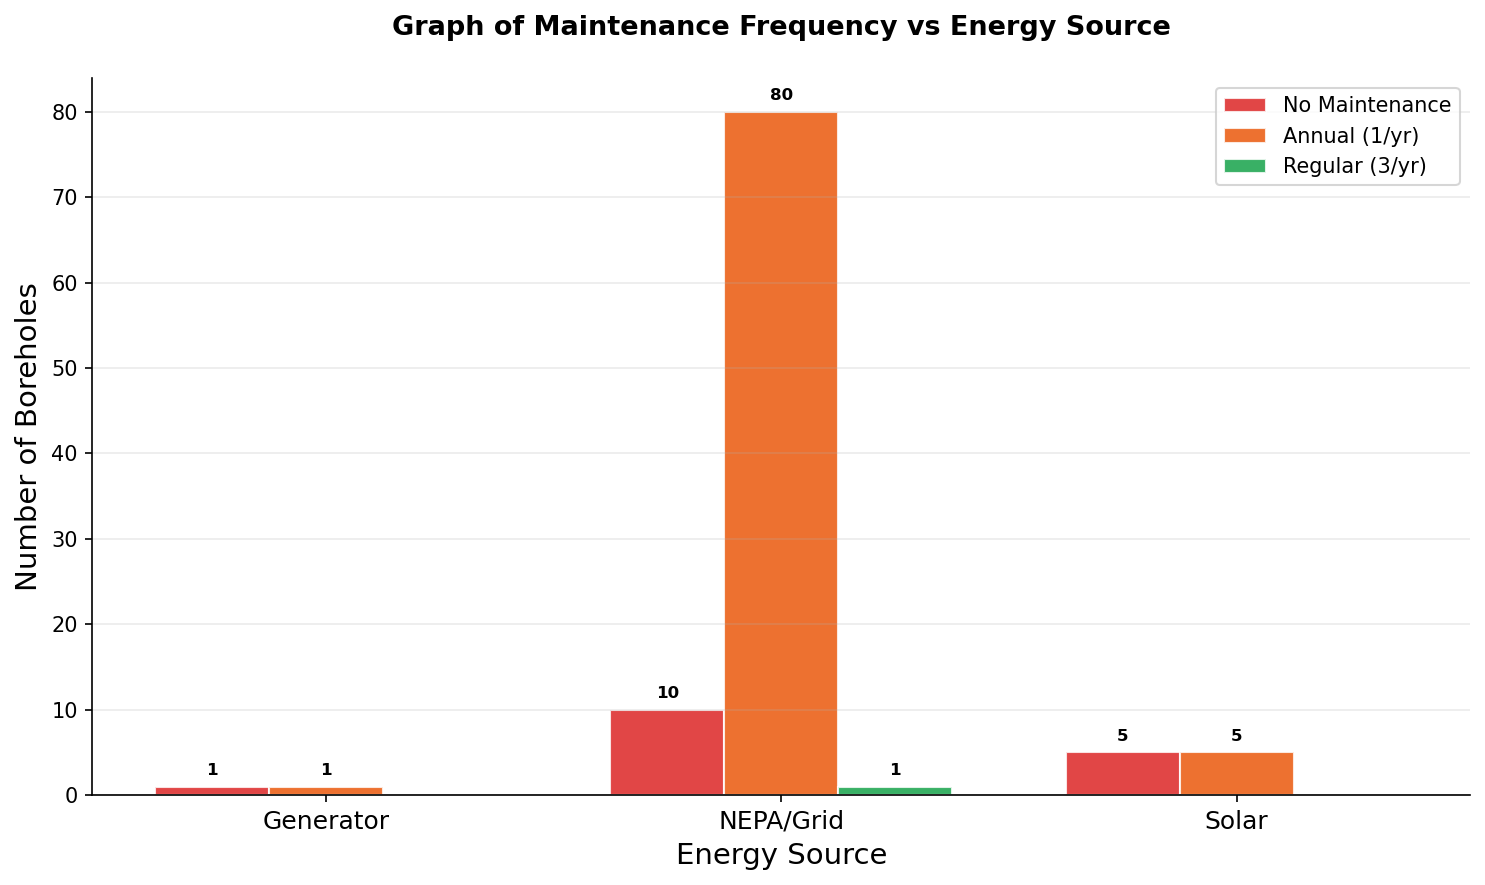

   ✅ Graph 7 saved


In [27]:
# ── GRAPH 7: Maintenance Frequency vs Energy Source ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
energy_maint = data.groupby(['Energy_Source','Maintenance_Freq']).size().unstack(fill_value=0)
energy_maint = energy_maint.reindex(columns=[0.0,1.0,3.0], fill_value=0)
bar_width = 0.25
x = np.arange(len(energy_maint))
maint_labels_map = {0.0:'No Maintenance', 1.0:'Annual (1/yr)', 3.0:'Regular (3/yr)'}
for idx, (freq, color) in enumerate(zip([0.0,1.0,3.0],[C['red'],C['orange'],C['green']])):
    if freq in energy_maint.columns:
        bars = ax.bar(x+idx*bar_width, energy_maint[freq].values,
                      width=bar_width, label=maint_labels_map[freq],
                      color=color, alpha=0.85, edgecolor='white')
        for bar in bars:
            if bar.get_height()>0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                        str(int(bar.get_height())), ha='center', va='bottom',
                        fontsize=8, fontweight='bold')
ax.set_xticks(x+bar_width); ax.set_xticklabels(energy_maint.index, fontsize=12)
ax.set_title('Graph of Maintenance Frequency vs Energy Source\n', fontsize=13, fontweight='bold')
ax.set_xlabel('Energy Source', fontsize=14); ax.set_ylabel('Number of Boreholes', fontsize=14)
ax.legend(fontsize=10); ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('graph7_maintenance_freq_vs_energy_source.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 7 saved")

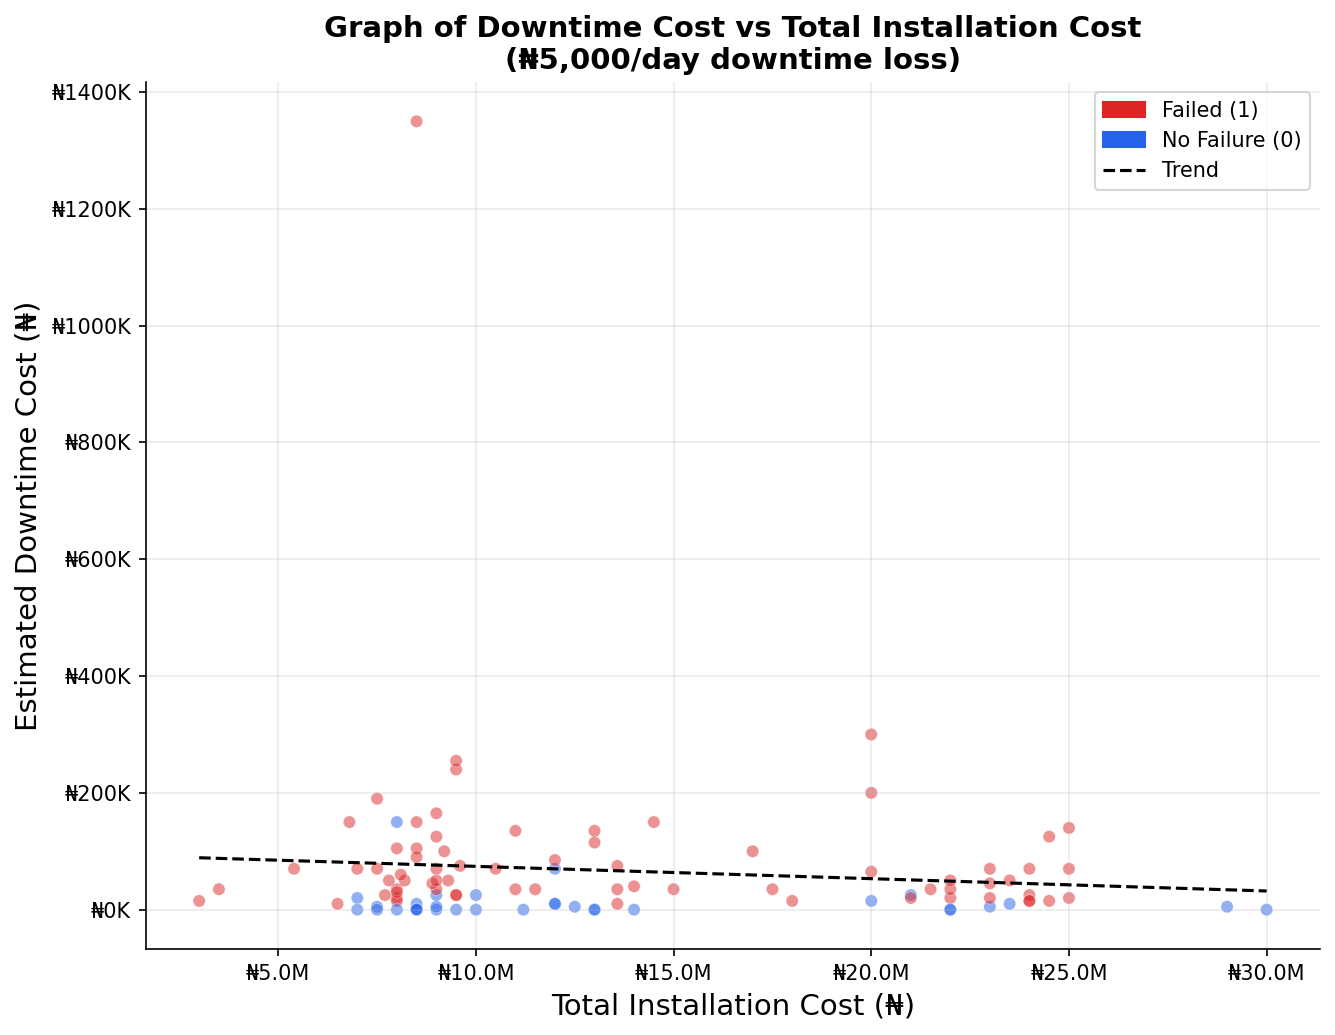

   ✅ Graph 8 saved


In [32]:
# ── GRAPH 8: Repair Cost vs Total Installation Cost ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
DAILY_LOSS = 5000
data['Downtime_Cost'] = data['Downtime(days)'] * DAILY_LOSS
colors_scatter = [C['red'] if f==1 else C['blue'] for f in data['Failure']]
ax.scatter(data['Total_Installation_Cost'], data['Downtime_Cost'],
           c=colors_scatter, s=35, alpha=0.5, edgecolors='white', linewidth=0.3)
mask = data['Total_Installation_Cost'] > 0
z = np.polyfit(data.loc[mask,'Total_Installation_Cost'], data.loc[mask,'Downtime_Cost'], 1)
cost_line = np.linspace(data['Total_Installation_Cost'].min(), data['Total_Installation_Cost'].max(), 200)
ax.plot(cost_line, np.poly1d(z)(cost_line), color='black', lw=1.5,
        linestyle='--', label='Trend Line')
red_patch  = mpatches.Patch(color=C['red'],  label='Failed (1)')
blue_patch = mpatches.Patch(color=C['blue'], label='No Failure (0)')
ax.legend(handles=[red_patch, blue_patch,
                   plt.Line2D([0],[0],color='black',linestyle='--',label='Trend')], fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₦{x/1_000_000:.1f}M' if x>=1_000_000 else f'₦{x/1_000:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₦{x/1_000:.0f}K'))
ax.set_title('Graph of Downtime Cost vs Total Installation Cost\n(₦5,000/day downtime loss)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Installation Cost (₦)', fontsize=14)
ax.set_ylabel('Estimated Downtime Cost (₦)', fontsize=14)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('graph8_repair_cost_vs_installation_cost.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 8 saved")

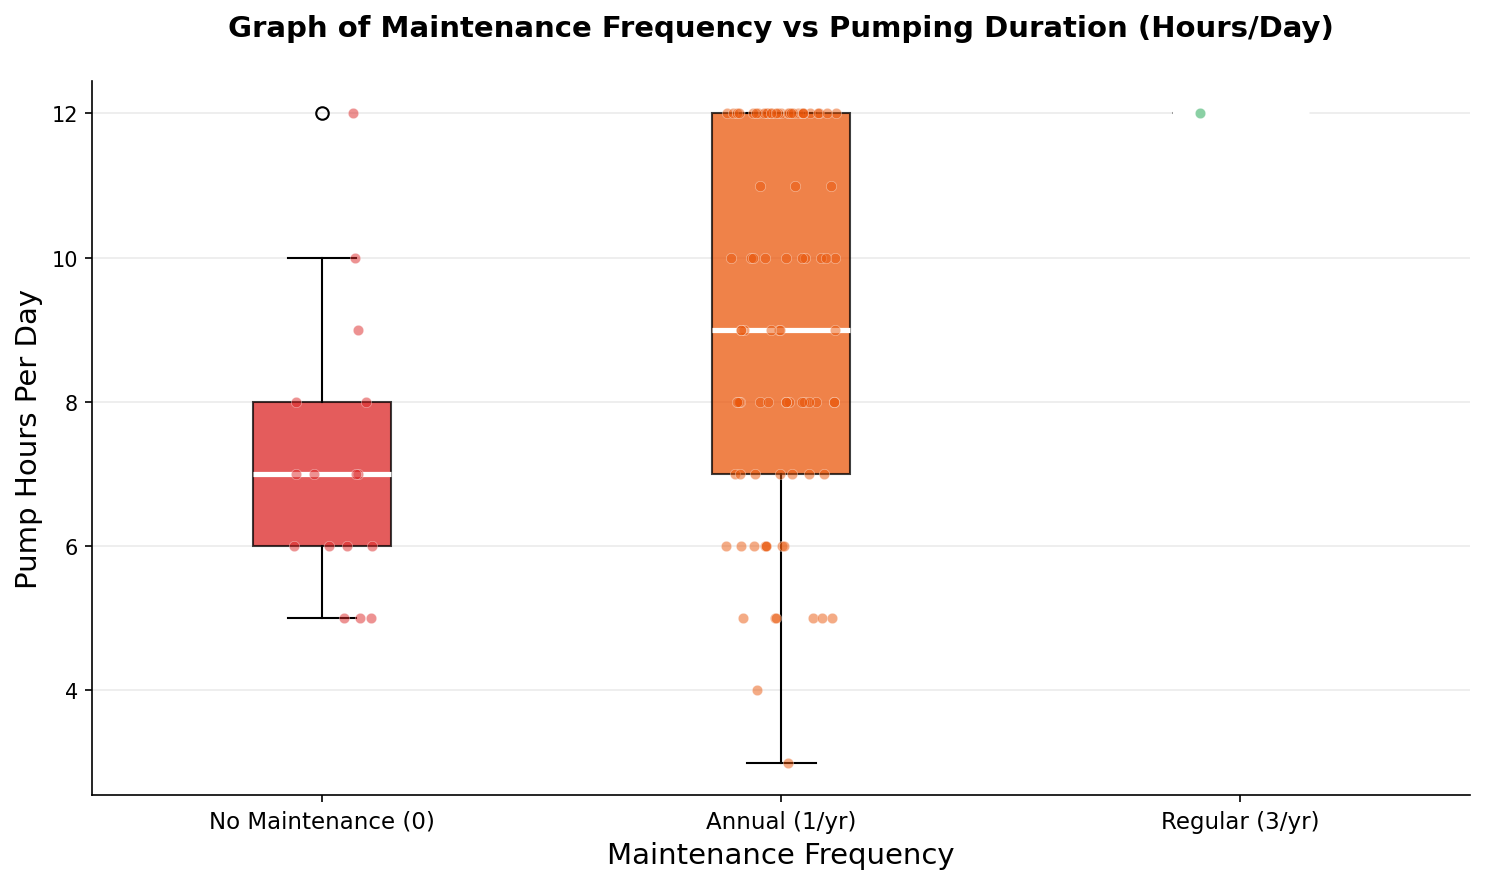

   ✅ Graph 9 saved


In [36]:
# ── GRAPH 9: Maintenance Frequency vs Pumping Duration ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
maint_pump_data = [data[data['Maintenance_Freq']==f]['Pump_Hours'].values for f in [0.0,1.0,3.0]]
maint_pump_colors = [C['red'], C['orange'], C['green']]
maint_pump_labels = ['No Maintenance (0)', 'Annual (1/yr)', 'Regular (3/yr)']
bp = ax.boxplot(maint_pump_data, patch_artist=True, medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], maint_pump_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (data_pts, color) in enumerate(zip(maint_pump_data, maint_pump_colors), 1):
    jitter = np.random.uniform(-0.12, 0.12, len(data_pts))
    ax.scatter(i+jitter, data_pts, color=color, s=25, alpha=0.5,
               edgecolors='white', linewidth=0.3, zorder=3)
ax.set_xticks([1,2,3]); ax.set_xticklabels(maint_pump_labels, fontsize=11)
ax.set_title('Graph of Maintenance Frequency vs Pumping Duration (Hours/Day)\n', fontsize=14, fontweight='bold')
ax.set_xlabel('Maintenance Frequency', fontsize=14)
ax.set_ylabel('Pump Hours Per Day', fontsize=14)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('graph9_maintenance_freq_vs_pump_duration.png', bbox_inches='tight')
plt.show()
print("   ✅ Graph 9 saved")
